# NFL Season Analysis
![NFL Logo](images/NFL.jpg "NFL")

In this NFL Analysis, metrics dubbed **Offense Rank**, **Defense Rank**, and **Combined Rank** are created to measure the profiency of a team's offense and defense. The team with the most **PTS FOR** in a season is given Rank 1 for offense, the team with the 2nd most **PTS FOR** in a season is given Rank 2, and so on. For defense, the team with the lowest **PTS AGAINST** is given a Rank 1 for defense, the team with the 2nd fewest **PTS AGAINST** is given Rank 2 and so on. Additionally, **Combined Rank** is the mean of **Offense Rank** and **Defense Rank** and measures how good a team is overall. Based on these metrics, the analysis looks at whether the team makes/misses the playoffs, and wins/loses the Super Bowl.

All of the data is from [Pro Football Reference](https://www.pro-football-reference.com/) and covers the NFL seasons from 2000-2024. 

# Code
The following code merges, cleans and calculates the relevant data.

In [42]:
# Libraries
import pandas as pd
import numpy as np

# rename columns
def rename_columns(df):
    df = df.rename(columns={
        'Tm':'Team',
        'W':'Wins',
        'L':'Losses',
        'W-L%':'Winning %',
        'PF':'Points For',
        'PA':'Points Against',
        'PD':'Points Differential',
        'MV':'Margin of Victory',
        'SoS':'Strength of Schedule',
        'SRS':'Simple Rating System',
        'OSRS':'Offense SRS',
        'DSRS':'Defense SRS'
    })
    return df

# create columns for made playoffs, wild card and division winner
def made_playoffs(df):
    df['Wild Card'] = np.where(df['Team'].str.contains(r'\+'), 'Yes', 'No')
    df['Division Winner'] = np.where(df['Team'].str.contains(r'\*'), 'Yes', 'No')
    df['Made Playoffs'] = np.where(df['Team'].str.contains(r'[*+]'), 'Yes', 'No')
    return df

# clean team names
def clean_names(df):
    df['Team'] = df['Team'].str.replace(r'[*+]', '', regex=True)
    return df

# read csv file, rename columns, add columns & clean names
def get_file_data(year, league):
    file_name = f'season data/{year} - {league}.csv'
    df = pd.read_csv(file_name)
    df = rename_columns(df)
    df = made_playoffs(df)
    df = clean_names(df)
    return df

# add made divisional series column
def made_divisoinal_series(df, year):
    playoffs = pd.read_csv(f'season data/{year} - playoffs.csv')
    made_divisional_teams = playoffs.loc[
        (playoffs['Week'] == 'Division'),
        ['Winner/tie', 'Loser/tie']
    ].values.flatten()
    df['Made Divisional Series'] = np.where(df['Team'].isin(made_divisional_teams), 'Yes', 'No')
    return df

# add made conference finals column
def made_conference_finals(df, year):
    playoffs = pd.read_csv(f'season data/{year} - playoffs.csv')
    made_conf_teams = playoffs.loc[
        (playoffs['Week'] == 'ConfChamp'),
        ['Winner/tie', 'Loser/tie']
    ].values.flatten()
    df['Made Conference Finals'] = np.where(df['Team'].isin(made_conf_teams), 'Yes', 'No')
    return df

# add made super bowl column
def made_superbowl(df, year):
    playoffs = pd.read_csv(f'season data/{year} - playoffs.csv')
    made_superbowl_teams = playoffs.loc[
        (playoffs['Week'] == 'SuperBowl'),
        ['Winner/tie', 'Loser/tie']
    ].values[0]
    df['Made Super Bowl'] = np.where(df['Team'].isin(made_superbowl_teams), 'Yes', 'No')
    return df

# add won super bowl column
def won_superbowl(df, year):
    playoffs = pd.read_csv(f'season data/{year} - playoffs.csv')
    superbowl_winner = playoffs.loc[
        (playoffs['Week'] == 'SuperBowl'),
        'Winner/tie'
    ].values
    df['Won Super Bowl'] = np.where(df['Team'].isin(superbowl_winner), 'Yes', 'No')
    return df

# calculate offense, defense and combined ranks
def off_def_ranks(df):
    df['Offense Rank'] = df['Points For'].rank(method='first', ascending=False).astype('int64')
    df['Defense Rank'] = df['Points Against'].rank(method='first', ascending=True).astype('int64')
    df['Combined Rank'] = (df['Offense Rank'] + df['Defense Rank'])/2
    return df

# putting it all together for one season
def combine_nfc_afc_data(year):
    afc = get_file_data(year, 'afc')
    nfc = get_file_data(year, 'nfc')
    df = pd.concat([afc, nfc])
    df = df.reset_index(drop=True)
    df = off_def_ranks(df)
    df = made_divisoinal_series(df, year)
    df = made_conference_finals(df, year)
    df = won_superbowl(df, year)
    df = made_superbowl(df, year)
    df['Season'] = year
    df = df[['Season' ,'Team', 'Points For', 'Points Against', 'Offense Rank', 'Defense Rank', 'Combined Rank', 'Made Playoffs', 'Division Winner', 'Wild Card', 'Made Divisional Series', 'Made Conference Finals', 'Made Super Bowl', 'Won Super Bowl']]
    return df

# combine data from all seasons
def get_data_multiple_years(start, end):
    dfs = pd.DataFrame()
    for year in range(start, end+1):
        df = combine_nfc_afc_data(year)
        dfs = pd.concat([dfs, df])
    return dfs

# get data for seasons from 2000-2024
final_df = get_data_multiple_years(2000, 2024)

In [43]:
# Preview of Data
final_df.head()

,Season,Team,Points For,Points Against,Offense Rank,Defense Rank,Combined Rank,Made Playoffs,Division Winner,Wild Card,Made Divisional Series,Made Conference Finals,Made Super Bowl,Won Super Bowl
0,2000,Miami Dolphins,323,226,16,3,9.5,Yes,Yes,No,Yes,No,No,No
1,2000,Indianapolis Colts,429,326,4,15,9.5,Yes,No,Yes,No,No,No,No
2,2000,New York Jets,321,321,17,13,15.0,No,No,No,No,No,No,No
3,2000,Buffalo Bills,315,350,20,18,19.0,No,No,No,No,No,No,No
4,2000,New England Patriots,276,338,25,17,21.0,No,No,No,No,No,No,No


# Super Bowl Appearances by Season, SB Winner
This is a table of all teams that made the Super Bowl. It is ordered with the earlier Seasons first and then by the team that won the Super Bowl.

In [44]:
# Super Bowl Appearances by Season, SB Winner
final_df[
    (final_df['Made Super Bowl'] == 'Yes')
    ].sort_values(['Season', 'Won Super Bowl'], ascending=[True, False])

,Season,Team,Points For,Points Against,Offense Rank,Defense Rank,Combined Rank,Made Playoffs,Division Winner,Wild Card,Made Divisional Series,Made Conference Finals,Made Super Bowl,Won Super Bowl
6,2000,Baltimore Ravens,333,165,14,1,7.5,Yes,No,Yes,Yes,Yes,Yes,Yes
16,2000,New York Giants,328,246,15,5,10.0,Yes,Yes,No,Yes,Yes,Yes,No
0,2001,New England Patriots,371,272,6,6,6.0,Yes,Yes,No,Yes,Yes,Yes,Yes
26,2001,St. Louis Rams,503,273,1,7,4.0,Yes,Yes,No,Yes,Yes,Yes,No
24,2002,Tampa Bay Buccaneers,346,196,18,1,9.5,Yes,Yes,No,Yes,Yes,Yes,Yes
12,2002,Oakland Raiders,450,304,2,6,4.0,Yes,Yes,No,Yes,Yes,Yes,No
0,2003,New England Patriots,348,238,12,1,6.5,Yes,Yes,No,Yes,Yes,Yes,Yes
24,2003,Carolina Panthers,325,304,15,10,12.5,Yes,Yes,No,Yes,Yes,Yes,No
0,2004,New England Patriots,437,260,4,2,3.0,Yes,Yes,No,Yes,Yes,Yes,Yes
16,2004,Philadelphia Eagles,386,260,8,3,5.5,Yes,Yes,No,Yes,Yes,Yes,No


# All Super Bowl Winners by Season
This is a table of all the Super Bowl winners ordered with the earlier seasons first.

In [45]:
# All Super Bowl Winners by Season
final_df[final_df['Won Super Bowl'] == 'Yes'].sort_values('Season')

,Season,Team,Points For,Points Against,Offense Rank,Defense Rank,Combined Rank,Made Playoffs,Division Winner,Wild Card,Made Divisional Series,Made Conference Finals,Made Super Bowl,Won Super Bowl
6,2000,Baltimore Ravens,333,165,14,1,7.5,Yes,No,Yes,Yes,Yes,Yes,Yes
0,2001,New England Patriots,371,272,6,6,6.0,Yes,Yes,No,Yes,Yes,Yes,Yes
24,2002,Tampa Bay Buccaneers,346,196,18,1,9.5,Yes,Yes,No,Yes,Yes,Yes,Yes
0,2003,New England Patriots,348,238,12,1,6.5,Yes,Yes,No,Yes,Yes,Yes,Yes
0,2004,New England Patriots,437,260,4,2,3.0,Yes,Yes,No,Yes,Yes,Yes,Yes
5,2005,Pittsburgh Steelers,389,258,9,3,6.0,Yes,No,Yes,Yes,Yes,Yes,Yes
8,2006,Indianapolis Colts,427,360,2,23,12.5,Yes,Yes,No,Yes,Yes,Yes,Yes
17,2007,New York Giants,373,351,14,17,15.5,Yes,No,Yes,Yes,Yes,Yes,Yes
4,2008,Pittsburgh Steelers,347,223,20,1,10.5,Yes,Yes,No,Yes,Yes,Yes,Yes
24,2009,New Orleans Saints,510,341,1,20,10.5,Yes,Yes,No,Yes,Yes,Yes,Yes


# Best Teams to Miss Playoffs

In [46]:
# Best Teams to Miss Playoffs
final_df[
    (final_df['Made Playoffs'] == 'No')
    ].sort_values(['Combined Rank']).head(20)

,Season,Team,Points For,Points Against,Offense Rank,Defense Rank,Combined Rank,Made Playoffs,Division Winner,Wild Card,Made Divisional Series,Made Conference Finals,Made Super Bowl,Won Super Bowl
13,2010,San Diego Chargers,441,322,2,10,6.0,No,No,No,No,No,No,No
10,2006,Jacksonville Jaguars,371,274,9,4,6.5,No,No,No,No,No,No,No
2,2004,Buffalo Bills,395,284,7,8,7.5,No,No,No,No,No,No,No
5,2017,Baltimore Ravens,395,303,9,6,7.5,No,No,No,No,No,No,No
13,2017,Los Angeles Chargers,355,272,13,3,8.0,No,No,No,No,No,No,No
2,2002,Miami Dolphins,378,301,12,4,8.0,No,No,No,No,No,No,No
1,2008,New England Patriots,410,309,8,8,8.0,No,No,No,No,No,No,No
17,2019,Dallas Cowboys,434,321,6,11,8.5,No,No,No,No,No,No,No
25,2023,New Orleans Saints,402,327,9,8,8.5,No,No,No,No,No,No,No
13,2014,Kansas City Chiefs,353,281,16,2,9.0,No,No,No,No,No,No,No


# Worst Teams to Make Playoffs

In [47]:
# Worst Teams to Make Playoffs
final_df[
    (final_df['Made Playoffs'] == 'Yes')
    ].sort_values(['Combined Rank'], ascending=False).head(20)

,Season,Team,Points For,Points Against,Offense Rank,Defense Rank,Combined Rank,Made Playoffs,Division Winner,Wild Card,Made Divisional Series,Made Conference Finals,Made Super Bowl,Won Super Bowl
12,2011,Denver Broncos,309,390,25,24,24.5,Yes,Yes,No,Yes,No,No,No
28,2010,Seattle Seahawks,310,407,23,25,24.0,Yes,Yes,No,Yes,No,No,No
29,2004,St. Louis Rams,319,392,19,25,22.0,Yes,No,Yes,Yes,No,No,No
13,2021,Las Vegas Raiders,374,439,18,26,22.0,Yes,No,Yes,No,No,No,No
5,2021,Pittsburgh Steelers,343,398,21,20,20.5,Yes,No,Yes,No,No,No,No
24,2014,Carolina Panthers,339,374,19,21,20.0,Yes,Yes,No,Yes,No,No,No
1,2017,Buffalo Bills,302,359,22,18,20.0,Yes,No,Yes,No,No,No,No
9,2012,Indianapolis Colts,357,387,18,21,19.5,Yes,No,Yes,No,No,No,No
8,2016,Houston Texans,279,328,28,11,19.5,Yes,Yes,No,Yes,No,No,No
24,2022,Tampa Bay Buccaneers,313,358,25,13,19.0,Yes,Yes,No,No,No,No,No


# Worst Teams to appear in Super Bowl

In [48]:
# Worst Super Bowl Teams
final_df[
    (final_df['Made Super Bowl'] == 'Yes')
    ].sort_values('Combined Rank', ascending=False).head(10)

,Season,Team,Points For,Points Against,Offense Rank,Defense Rank,Combined Rank,Made Playoffs,Division Winner,Wild Card,Made Divisional Series,Made Conference Finals,Made Super Bowl,Won Super Bowl
16,2011,New York Giants,394,400,9,25,17.0,Yes,Yes,No,Yes,Yes,Yes,Yes
28,2008,Arizona Cardinals,427,426,4,28,16.0,Yes,Yes,No,Yes,Yes,Yes,No
17,2007,New York Giants,373,351,14,17,15.5,Yes,No,Yes,Yes,Yes,Yes,Yes
24,2016,Atlanta Falcons,540,406,1,27,14.0,Yes,Yes,No,Yes,Yes,Yes,No
24,2003,Carolina Panthers,325,304,15,10,12.5,Yes,Yes,No,Yes,Yes,Yes,No
8,2006,Indianapolis Colts,427,360,2,23,12.5,Yes,Yes,No,Yes,Yes,Yes,Yes
4,2021,Cincinnati Bengals,460,376,7,17,12.0,Yes,Yes,No,Yes,Yes,Yes,No
28,2021,Los Angeles Rams,460,372,8,15,11.5,Yes,Yes,No,Yes,Yes,Yes,Yes
12,2015,Denver Broncos,355,296,19,4,11.5,Yes,Yes,No,Yes,Yes,Yes,Yes
12,2013,Denver Broncos,606,399,1,22,11.5,Yes,Yes,No,Yes,Yes,Yes,No


# Top 5 Defenses to win Super Bowl

In [49]:
# Top 5 Defenses to win Super Bowl
top5_defense = final_df[
    (final_df['Won Super Bowl'] == 'Yes') & (final_df['Defense Rank'] <= 5)
    ].sort_values('Season', ascending=True).reset_index(drop=True)

top5_defense

,Season,Team,Points For,Points Against,Offense Rank,Defense Rank,Combined Rank,Made Playoffs,Division Winner,Wild Card,Made Divisional Series,Made Conference Finals,Made Super Bowl,Won Super Bowl
0,2000,Baltimore Ravens,333,165,14,1,7.5,Yes,No,Yes,Yes,Yes,Yes,Yes
1,2002,Tampa Bay Buccaneers,346,196,18,1,9.5,Yes,Yes,No,Yes,Yes,Yes,Yes
2,2003,New England Patriots,348,238,12,1,6.5,Yes,Yes,No,Yes,Yes,Yes,Yes
3,2004,New England Patriots,437,260,4,2,3.0,Yes,Yes,No,Yes,Yes,Yes,Yes
4,2005,Pittsburgh Steelers,389,258,9,3,6.0,Yes,No,Yes,Yes,Yes,Yes,Yes
5,2008,Pittsburgh Steelers,347,223,20,1,10.5,Yes,Yes,No,Yes,Yes,Yes,Yes
6,2010,Green Bay Packers,388,240,10,2,6.0,Yes,No,Yes,Yes,Yes,Yes,Yes
7,2013,Seattle Seahawks,417,231,9,1,5.0,Yes,Yes,No,Yes,Yes,Yes,Yes
8,2015,Denver Broncos,355,296,19,4,11.5,Yes,Yes,No,Yes,Yes,Yes,Yes
9,2016,New England Patriots,441,250,3,1,2.0,Yes,Yes,No,Yes,Yes,Yes,Yes


# Top 5 Offenses to win Super Bowl

In [50]:
# Top 5 Offenses to win Super Bowl
top5_offense = final_df[
    (final_df['Won Super Bowl'] == 'Yes') & (final_df['Offense Rank'] <= 5)
    ].sort_values('Season', ascending=True).reset_index(drop=True)

top5_offense

,Season,Team,Points For,Points Against,Offense Rank,Defense Rank,Combined Rank,Made Playoffs,Division Winner,Wild Card,Made Divisional Series,Made Conference Finals,Made Super Bowl,Won Super Bowl
0,2004,New England Patriots,437,260,4,2,3.0,Yes,Yes,No,Yes,Yes,Yes,Yes
1,2006,Indianapolis Colts,427,360,2,23,12.5,Yes,Yes,No,Yes,Yes,Yes,Yes
2,2009,New Orleans Saints,510,341,1,20,10.5,Yes,Yes,No,Yes,Yes,Yes,Yes
3,2014,New England Patriots,468,313,4,8,6.0,Yes,Yes,No,Yes,Yes,Yes,Yes
4,2016,New England Patriots,441,250,3,1,2.0,Yes,Yes,No,Yes,Yes,Yes,Yes
5,2017,Philadelphia Eagles,457,295,3,4,3.5,Yes,Yes,No,Yes,Yes,Yes,Yes
6,2018,New England Patriots,436,325,4,7,5.5,Yes,Yes,No,Yes,Yes,Yes,Yes
7,2019,Kansas City Chiefs,451,308,5,7,6.0,Yes,Yes,No,Yes,Yes,Yes,Yes
8,2020,Tampa Bay Buccaneers,492,355,3,8,5.5,Yes,No,Yes,Yes,Yes,Yes,Yes
9,2022,Kansas City Chiefs,496,369,1,16,8.5,Yes,Yes,No,Yes,Yes,Yes,Yes


# ANOVA & Mutual Information Statistic

In [51]:
##### Feature Importance #####
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

def make_mi_scores(x_data, y_data, Title):
    # columns to consider
    X = x_data
    y = LabelEncoder().fit_transform(y_data)
    
    # calculate mi
    mi_scores = mutual_info_classif(X, y, discrete_features=False, random_state=2022)
    # make df of mi
    mi_scores_df = pd.DataFrame({'Feature': X.columns, 'MI Scores': mi_scores}).sort_values('MI Scores', ascending=False)
    # bar plot
    sns.barplot(y='Feature', x='MI Scores', data = mi_scores_df, color='black')
    plt.title(f'Mutual Information Statistic for {Title}')
    plt.show()
    display(mi_scores_df)

## Made Playoffs

In [52]:
# Offense
import pingouin as pg
pg.anova(data=final_df, dv='Points For', between='Made Playoffs', detailed=False)

,Source,ddof1,ddof2,F,p_unc,np2
0,Made Playoffs,1,796,402.212473,9.868473e-73,0.335677


In [53]:
# Defense
import pingouin as pg
pg.anova(data=final_df, dv='Points Against', between='Made Playoffs', detailed=False)

,Source,ddof1,ddof2,F,p_unc,np2
0,Made Playoffs,1,796,270.428319,1.564213e-52,0.253583


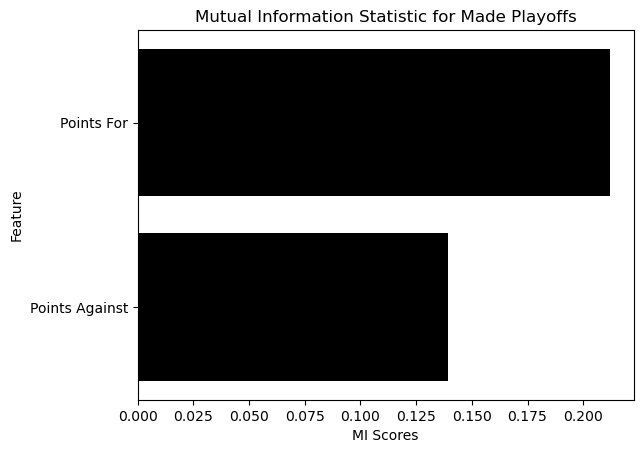

,Feature,MI Scores
0,Points For,0.212024
1,Points Against,0.139145


In [54]:
x_data = final_df[['Points For', 'Points Against']]
y_data = final_df['Made Playoffs']

make_mi_scores(x_data, y_data, 'Made Playoffs')

## Made Divisional Series

In [55]:
# Offense
import pingouin as pg
pg.anova(data=final_df, dv='Points For', between='Made Divisional Series', detailed=False)

,Source,ddof1,ddof2,F,p_unc,np2
0,Made Divisional Series,1,796,253.110719,1.083731e-49,0.241262


In [56]:
# Defense
import pingouin as pg
pg.anova(data=final_df, dv='Points Against', between='Made Divisional Series', detailed=False)

,Source,ddof1,ddof2,F,p_unc,np2
0,Made Divisional Series,1,796,194.780234,9.263797e-40,0.196593


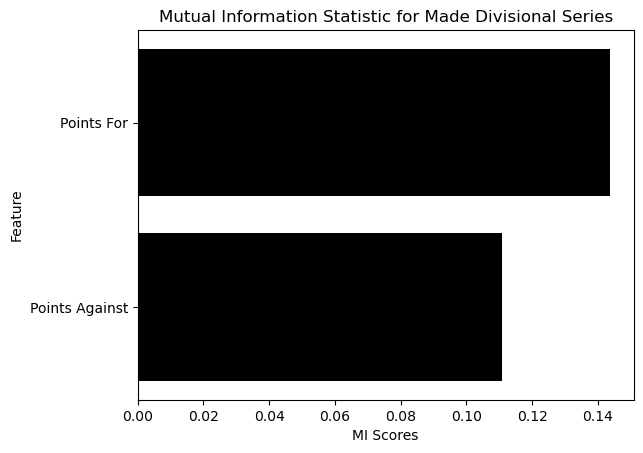

,Feature,MI Scores
0,Points For,0.143681
1,Points Against,0.110951


In [57]:
x_data = final_df[['Points For', 'Points Against']]
y_data = final_df['Made Divisional Series']

make_mi_scores(x_data, y_data, 'Made Divisional Series')

## Made Conference Finals

In [58]:
# Offense
import pingouin as pg
pg.anova(data=final_df, dv='Points For', between='Made Conference Finals', detailed=False)

,Source,ddof1,ddof2,F,p_unc,np2
0,Made Conference Finals,1,796,138.983281,1.110901e-29,0.148648


In [59]:
# Defense
import pingouin as pg
pg.anova(data=final_df, dv='Points Against', between='Made Conference Finals', detailed=False)

,Source,ddof1,ddof2,F,p_unc,np2
0,Made Conference Finals,1,796,92.707489,7.852322e-21,0.104317


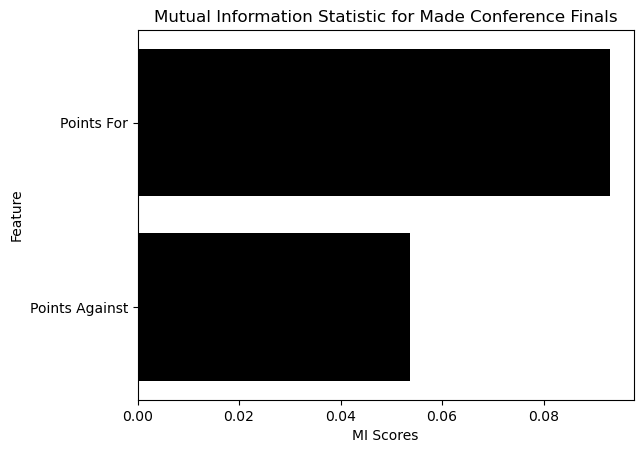

,Feature,MI Scores
0,Points For,0.093113
1,Points Against,0.053718


In [60]:
x_data = final_df[['Points For', 'Points Against']]
y_data = final_df['Made Conference Finals']

make_mi_scores(x_data, y_data, 'Made Conference Finals')

# Making Super Bowl

In [61]:
# Offense
import pingouin as pg
pg.anova(data=final_df, dv='Points For', between='Made Super Bowl', detailed=False)

,Source,ddof1,ddof2,F,p_unc,np2
0,Made Super Bowl,1,796,66.674872,1.250992e-15,0.077289


In [62]:
# Defense
import pingouin as pg
pg.anova(data=final_df, dv='Points Against', between='Made Super Bowl', detailed=False)

,Source,ddof1,ddof2,F,p_unc,np2
0,Made Super Bowl,1,796,44.851928,4.014880e-11,0.053341


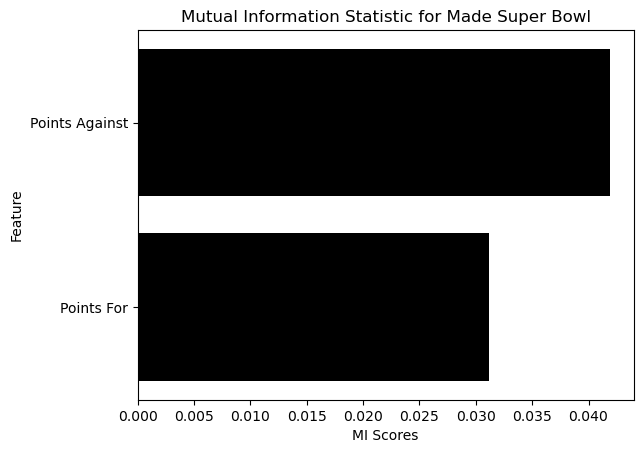

,Feature,MI Scores
1,Points Against,0.041909
0,Points For,0.031143


In [63]:
x_data = final_df[['Points For', 'Points Against']]
y_data = final_df['Made Super Bowl']

make_mi_scores(x_data, y_data, 'Made Super Bowl')

## Won Super Bowl

In [68]:
# Offense
import pingouin as pg
pg.anova(data=final_df, dv='Points For', between='Won Super Bowl', detailed=False)

,Source,ddof1,ddof2,F,p_unc,np2
0,Won Super Bowl,1,796,16.684127,0.000049,0.02053


In [69]:
# Defense
import pingouin as pg
pg.anova(data=final_df, dv='Points Against', between='Won Super Bowl', detailed=False)

,Source,ddof1,ddof2,F,p_unc,np2
0,Won Super Bowl,1,796,29.524036,7.344990e-08,0.035764


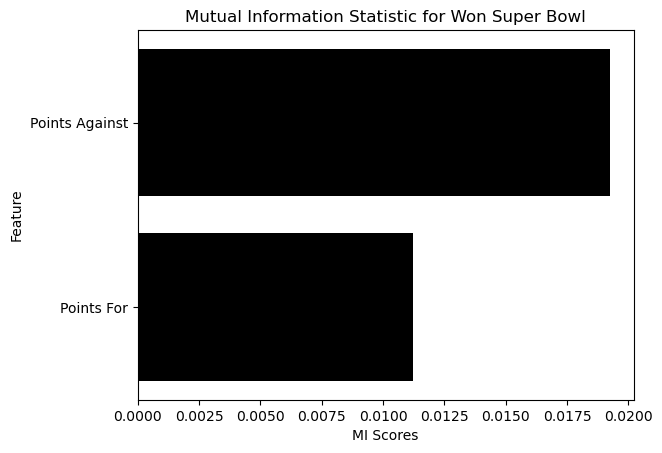

,Feature,MI Scores
1,Points Against,0.019248
0,Points For,0.011233


In [70]:
x_data = final_df[['Points For', 'Points Against']]
y_data = final_df['Won Super Bowl']

make_mi_scores(x_data, y_data, 'Won Super Bowl')

Your offense and defense during the season dictates how well teams do in the playoffs. Based on their numbers over the course of the season, the following conclusions can be reached,

Offense More Important:
1. Making Playoffs
2. Making Divisional Series
3. Making Confeerence Finals

Defense More Important:
1. Making Superbowl
2. Winning Superbowl

In [71]:
final_df.to_csv('nfl_data.csv')